# Description

# Modules

In [1]:
import re
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from data.recount2 import LVAnalysis
from utils import chunker
import conf

# Settings

Specify below the LV id you are interested in:

In [2]:
LV_NAME = "LV925"

# Paths

These are paths to folder and files where we'll save our figures.

In [3]:
OUTPUT_FIGURES_DIR = Path(conf.RESULTS_DIR, "demo", f"{LV_NAME.lower()}").resolve()
display(OUTPUT_FIGURES_DIR)
OUTPUT_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

PosixPath('/opt/data/results/demo/lv925')

In [4]:
OUTPUT_CELL_TYPE_FILEPATH = OUTPUT_FIGURES_DIR / f"{LV_NAME.lower()}-cell_types.svg"
display(OUTPUT_CELL_TYPE_FILEPATH)

PosixPath('/opt/data/results/demo/lv925/lv925-cell_types.svg')

# Load MultiPLIER summary

In [5]:
multiplier_model_summary = pd.read_pickle(conf.MULTIPLIER["MODEL_SUMMARY_FILE"])

In [6]:
multiplier_model_summary.shape

(2157, 5)

In [7]:
multiplier_model_summary.head()

,pathway,LV index,AUC,p-value,FDR
1,KEGG_LYSINE_DEGRADATION,1,0.388059,0.866078,0.956005
2,REACTOME_MRNA_SPLICING,1,0.733057,0.000048,0.000582
3,MIPS_NOP56P_ASSOCIATED_PRE_RRNA_COMPLEX,1,0.680555,0.001628,0.011366
4,KEGG_DNA_REPLICATION,1,0.549473,0.312155,0.539951
5,PID_MYC_ACTIVPATHWAY,1,0.639303,0.021702,0.083739


# Load LV data

You can use the `LVAnalysis` class to explore an LV.

In [8]:
lv_obj = LVAnalysis(LV_NAME)

Here I show the top 20 genes for our LV. You can see gene symbols, the LV weight (in column `LV603`) and the cytoband.

In [9]:
lv_obj.lv_genes.head(20)

,gene_name,LV925,gene_band
0,RAB26,3.962000,16p13.3
1,CREB3L4,3.809981,1q21.3
2,ZNF552,2.676678,19q13.43
3,LINC00921,2.494355,16p13.3
4,TACR2,2.144907,10q22.1
5,NPB,1.993333,NaN
6,C11orf80,1.978051,11q13.2
7,NOXO1,1.867241,NaN
8,BAMBI,1.734197,10p12.1
9,REM2,1.718219,14q11.2


Show the pathways our LV is aligned to (neutrophils):

In [10]:
multiplier_model_summary[
    multiplier_model_summary["LV index"].isin((LV_NAME[2:],))
    & (
        (multiplier_model_summary["FDR"] < 0.05)
        & (multiplier_model_summary["AUC"] >= 0.75)
    )
]

[2025-04-22 21:59:22,057 - numexpr.utils] INFO: Note: NumExpr detected 32 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 8.
[2025-04-22 21:59:22,057 - numexpr.utils] INFO: NumExpr defaulting to 8 threads.


,pathway,LV index,AUC,p-value,FDR


Here I load the LV metadata.
This is, for each sample from our matrix B, we load its metadata.
The `LVAnalysis` class takes care of downloading all necessary files from recount2.

In [11]:
lv_data = lv_obj.get_experiments_data()

SRP018256, SRP013239, SRP014688, SRP026204, SRP020561, SRP010907, SRP024674, SRP056296, SRP056802, SRP009266, SRP045391, SRP017330, SRP056201, SRP060416, SRP058722, SRP048811, SRP012546, SRP028887, SRP044608, SRP066834, SRP055569, SRP049713, SRP040418, SRP057196, SRP028170, SRP017631, SRP009862, SRP042161, SRP008145, SRP002326, SRP007461, SRP062230, SRP040278, SRP041471, SRP042620, SRP043593, SRP024669, SRP019994, SRP033248, SRP055512, SRP009247, SRP033282, SRP006575, SRP044610, SRP021214, SRP031476, SRP049355, SRP005967, SRP017777, SRP034007, SRP039359, SRP058773, SRP002915, SRP007508, SRP043962, SRP051628, SRP012461, SRP018838, SRP037971, SRP029334, SRP066356, SRP039397, SRP018853, SRP049823, SRP012098, SRP055153, 

/opt/code/libs/data/recount2.py:323: UserWarning: Not all experiments data could be loaded (62 != 66)
  warnings.warn(


In [12]:
lv_data.shape

(5496, 93)

In [13]:
lv_data.head()

cell line treatement time                       treatment  \
project   run                                                                   
SRP018256 SRR653421      MCF7               0                       untreated   
          SRR653422      MCF7               0                       untreated   
          SRR653423      MCF7              10  treated for 10 minutes with E2   
          SRR653424      MCF7              10  treated for 10 minutes with E2   
          SRR653425      MCF7              40  treated for 40 minutes with E2   

                    treatment time cell type individual assay replicate  \
project   run                                                             
SRP018256 SRR653421            NaN       NaN        NaN   NaN       NaN   
          SRR653422            NaN       NaN        NaN   NaN       NaN   
          SRR653423            NaN       NaN        NaN   NaN       NaN   
          SRR653424            NaN       NaN        NaN   NaN       NaN   
          SRR653425            NaN       NaN        NaN   NaN       NaN   

                    infected with time post infection  ... condition  \
project   run                                          ...             
SRP018256 SRR653421           NaN                 NaN  ...       NaN   
          SRR653422           NaN                 NaN  ...       NaN   
          SRR653423           NaN                 NaN  ...       NaN   
          SRR653424           NaN                 NaN  ...       NaN   
          SRR653425           NaN                 NaN  ...       NaN   

                    dynamic program knockdown status serum strain targeted by  \
project   run                                                                   
SRP018256 SRR653421             NaN       NaN    NaN   NaN    NaN         NaN   
          SRR653422             NaN       NaN    NaN   NaN    NaN         NaN   
          SRR653423             NaN       NaN    NaN   NaN    NaN         NaN   
          SRR653424             NaN       NaN    NaN   NaN    NaN         NaN   
          SRR653425             NaN       NaN    NaN   NaN    NaN         NaN   

                    catalog# vendor     LV925  
project   run                                  
SRP018256 SRR653421      NaN    NaN  1.967775  
          SRR653422      NaN    NaN  1.853175  
          SRR653423      NaN    NaN  1.588926  
          SRR653424      NaN    NaN  1.632622  
          SRR653425      NaN    NaN  1.868339  

[5 rows x 93 columns]

# LV cell types analysis

## Get top attributes

Here I quickly show the top attributes in our metadata for which we have the largest LV variance.
This is just to have an idea of the variance across different attributes

In [14]:
lv_attrs = lv_obj.get_attributes_variation_score()
display(lv_attrs.head(20))

assay                  0.257486
treatment time         0.224687
infected with          0.152310
time post infection    0.152310
molecule type          0.152310
individual             0.133533
cell line              0.078639
treatment              0.029993
transfected with       0.024610
molecule               0.023828
treatement time        0.021405
antibody               0.021217
replicate              0.018714
chip antibody          0.017720
treated with           0.014648
cell state             0.013998
purification           0.013787
sample type            0.013558
time                   0.011838
experiment             0.011528
dtype: float64

Since we are interested in cell types and tissues, the code below will find which attributes contain "cell type" or "tissue", so we can select from these results.

In [15]:
# show those with cell type or tissue in their name
_tmp = pd.Series(lv_attrs.index)
lv_attrs[
    _tmp.str.match(
        "(?:cell.*(type|line)$)|(?:tissue$)|(?:tissue.*type$)",
        case=False,
        flags=re.IGNORECASE,
    ).values
].sort_values(ascending=False)

cell line       0.078639
cell type       0.006984
cell subtype    0.005870
tissue          0.003757
dtype: float64

Select from the output above those you are interested in. Usually all of them.

In [16]:
lv_attrs_selected = [
    "cell line",
    "cell type",
    "cell subtype",
    "tissue"
]

In [17]:
_tmp = lv_data.loc[
    :,
    lv_attrs_selected + [LV_NAME],
]

In [18]:
_tmp_seq = list(chunker(_tmp.sort_values(LV_NAME, ascending=False), 25))

Now that we selected attributes that might be providing information about the cell type, we can see which are the top ones.

If you change the number in the cell below, you can paginate over the entire set of results; for example, with `_tmp_seq[1]` you'll see the next "page" in a descending order with respect to the LV value. So the ones at the top are the most important ones.

In [19]:
_tmp_seq[0]

cell line cell type cell subtype tissue     LV925
project   run                                                        
SRP018256 SRR653421      MCF7       NaN          NaN    NaN  1.967775
SRP013239 SRR497904      MCF7       NaN          NaN    NaN  1.892216
          SRR497906      MCF7       NaN          NaN    NaN  1.886486
SRP018256 SRR653425      MCF7       NaN          NaN    NaN  1.868339
SRP013239 SRR497905      MCF7       NaN          NaN    NaN  1.867609
SRP018256 SRR653422      MCF7       NaN          NaN    NaN  1.853175
SRP013239 SRR497920      MCF7       NaN          NaN    NaN  1.814641
          SRR497908      MCF7       NaN          NaN    NaN  1.781397
          SRR497917      MCF7       NaN          NaN    NaN  1.778907
          SRR497914      MCF7       NaN          NaN    NaN  1.771237
          SRR497907      MCF7       NaN          NaN    NaN  1.766542
          SRR497912      MCF7       NaN          NaN    NaN  1.764595
SRP018256 SRR653426      MCF7       NaN          NaN    NaN  1.760274
SRP013239 SRR497909      MCF7       NaN          NaN    NaN  1.758414
          SRR497913      MCF7       NaN          NaN    NaN  1.758160
          SRR497918      MCF7       NaN          NaN    NaN  1.758105
          SRR497916      MCF7       NaN          NaN    NaN  1.757674
          SRR497910      MCF7       NaN          NaN    NaN  1.729348
          SRR497923      MCF7       NaN          NaN    NaN  1.691748
          SRR497911      MCF7       NaN          NaN    NaN  1.689197
          SRR497921      MCF7       NaN          NaN    NaN  1.689118
SRP018256 SRR653424      MCF7       NaN          NaN    NaN  1.632622
SRP013239 SRR497922      MCF7       NaN          NaN    NaN  1.622976
          SRR497915      MCF7       NaN          NaN    NaN  1.589818
SRP018256 SRR653423      MCF7       NaN          NaN    NaN  1.588926

You can see above that the RNA-seq samples are from neutrophils or granulocytes.
If we move to the next "page", we'll see this:

In [20]:
_tmp_seq[1]

cell line    cell type cell subtype tissue     LV925
project   run                                                            
SRP014688 SRR531824        NaN      B-cells          NaN    NaN  0.986680
          SRR531825        NaN      B-cells          NaN    NaN  0.986174
          SRR531826        NaN      B-cells          NaN    NaN  0.909951
SRP026204 SRR915731        NaN          NaN          NaN    NaN  0.775537
SRP020561 SRR816998       MCF7          NaN          NaN    NaN  0.763215
          SRR817000       MCF7          NaN          NaN    NaN  0.739888
SRP010907 SRR408118       A549          NaN          NaN    NaN  0.731617
          SRR408117       A549          NaN          NaN    NaN  0.723775
SRP026204 SRR915734        NaN          NaN          NaN    NaN  0.714454
SRP010907 SRR408119       A549          NaN          NaN    NaN  0.712840
SRP026204 SRR915733        NaN          NaN          NaN    NaN  0.697468
          SRR915732        NaN          NaN          NaN    NaN  0.613690
SRP020561 SRR817001       MCF7          NaN          NaN    NaN  0.540525
SRP024674 SRR892028        NaN  LNCaP cells          NaN    NaN  0.539933
          SRR892025        NaN  LNCaP cells          NaN    NaN  0.526041
          SRR892030        NaN  LNCaP cells          NaN    NaN  0.506523
SRP056296 SRR1918760     MCF-7          NaN          NaN    NaN  0.500079
SRP056802 SRR1950491     Nalm6          NaN          NaN    NaN  0.494079
          SRR1950492     Nalm6          NaN          NaN    NaN  0.490305
SRP020561 SRR817002       MCF7          NaN          NaN    NaN  0.479569
          SRR816999       MCF7          NaN          NaN    NaN  0.474195
SRP056802 SRR1950512     Nalm6          NaN          NaN    NaN  0.468210
          SRR1950507     Nalm6          NaN          NaN    NaN  0.467784
          SRR1950511     Nalm6          NaN          NaN    NaN  0.462283
          SRR1950508     Nalm6          NaN          NaN    NaN  0.457943

Although the attributes we selected (`cell type`, `celltype` and `tissue`) seem to be enough for most of the RNA-seq samples to get their cell types, this is not the case for some of them. For example, we have empty values (NaN) for `SRP015360`.

You can explore the metadata provided for a particular SPR with the code below. Let's see what we have in `SRP015360`:

In [21]:
# list the top 10 samples from this project
lv_data.loc[["SRP018256"]].dropna(how="all", axis=1).sort_values(
    LV_NAME, ascending=False
).head(10)

cell line treatement time                       treatment  \
project   run                                                                   
SRP018256 SRR653421      MCF7               0                       untreated   
          SRR653425      MCF7              40  treated for 40 minutes with E2   
          SRR653422      MCF7               0                       untreated   
          SRR653426      MCF7              40  treated for 40 minutes with E2   
          SRR653424      MCF7              10  treated for 10 minutes with E2   
          SRR653423      MCF7              10  treated for 10 minutes with E2   

                        LV925  
project   run                  
SRP018256 SRR653421  1.967775  
          SRR653425  1.868339  
          SRR653422  1.853175  
          SRR653426  1.760274  
          SRR653424  1.632622  
          SRR653423  1.588926

So for `SRP015360` we only have three attributes: `age`, `Sex` and `treatment`. No cell type information. Here you can start grasping the challenges in analyzing this data.

If you are really interested in this metadata for this project, you can use this URL:
```
https://trace.ncbi.nlm.nih.gov/Traces/sra/?study=SRP015360
```
where you can put the SRP code you want. If you check the URL above, you'll see that these samples were taken from neutrophils as well (treated with different stimuli), although we don't have metadata about the cell type/tissue.

Ok, we do not want several attributes conveying the same information (cell types), just a single one, so here we'll combine the attributes we found before with a particular _order_.
In this case I select `cell type` _first_ (the order is important), `celltype` as second, and `tissue` as third/last.
This means that I will use the information in `cell type` first, but if this is empty (as in `SRP045500`), we'll try with `celltype`, and so on.

In [22]:
SELECTED_ATTRIBUTES = [
    "cell line",
    "cell type",
    "cell subtype",
    "tissue",
]

## Get a single attribute with "cell type/tissue" information

In [23]:
plot_data = lv_data.loc[:, SELECTED_ATTRIBUTES + [LV_NAME]]

In [24]:
# if blank/nan, fill cell type column with tissue content
_new_column = plot_data[SELECTED_ATTRIBUTES].fillna(method="backfill", axis=1)[
    SELECTED_ATTRIBUTES[0]
]
plot_data[SELECTED_ATTRIBUTES[0]] = _new_column
plot_data = plot_data.drop(columns=SELECTED_ATTRIBUTES[1:])
plot_data = plot_data.fillna({SELECTED_ATTRIBUTES[0]: "NOT CATEGORIZED"})

In [25]:
plot_data = plot_data.sort_values(LV_NAME, ascending=False)

In [26]:
plot_data.head(20)

cell line     LV925
project   run                          
SRP018256 SRR653421      MCF7  1.967775
SRP013239 SRR497904      MCF7  1.892216
          SRR497906      MCF7  1.886486
SRP018256 SRR653425      MCF7  1.868339
SRP013239 SRR497905      MCF7  1.867609
SRP018256 SRR653422      MCF7  1.853175
SRP013239 SRR497920      MCF7  1.814641
          SRR497908      MCF7  1.781397
          SRR497917      MCF7  1.778907
          SRR497914      MCF7  1.771237
          SRR497907      MCF7  1.766542
          SRR497912      MCF7  1.764595
SRP018256 SRR653426      MCF7  1.760274
SRP013239 SRR497909      MCF7  1.758414
          SRR497913      MCF7  1.758160
          SRR497918      MCF7  1.758105
          SRR497916      MCF7  1.757674
          SRR497910      MCF7  1.729348
          SRR497923      MCF7  1.691748
          SRR497911      MCF7  1.689197

You can see that now all attributes ("celltype", "cell type" and "tissue") are combined under a single attribute named "cell type".
For example, if you look at `SRP045500`, which had a value under "celltype" but an empty (NaN) value for attribute "cell type", that now the value was moved to "cell type" (it was unified into this single attribute).

If you see "NOT CATEGORIZED", it means that none of the attributes you used had a value (they were all empty or NaN). In this case you would go the URL before and read the article/RNA-seq data description to find out the cell type or tissue (or whatever attribute your are interested in).

## Standardize cell type names

When cell type values are different but represent the same cell type, we unify them:

In [27]:
final_plot_data = plot_data.replace(
    {
        SELECTED_ATTRIBUTES[0]: {
            # # neutrophils:
            # "primary human neutrophils": "Neutrophils",
            # "Neutrophil isolated from peripheral blood": "Neutrophils",
            # "Neutrophil": "Neutrophils",
            # "neutrophils (Neu)": "Neutrophils",
            # # granulocytes:
            # "granulocyte": "Granulocytes",
            # # monocytes:
            # "primary human monocytes": "Monocytes",
            # # whole blood:
            # #             "whole blood": "Whole blood",  # uncomment this line to merge occurences of "whole blood" into "Whole blood"
            # "Whole Blood": "Whole blood",
            # # PBMC:
            # "primary human PBMC": "PBMC",
            # # B-cells:
            # "primary human B cells": "B cells",
            # # T-cells:
            # "primary human T cells": "T cells",
            # # epithelial cells:
            # "epithelial cells (Epi)": "Epithelial cells",
            # "primary human myeloid DC": "mDCs",
        }
    }
)

The code below is more advanced, but you can use it to customize even further your final attribute value (for example, if you want to use the cell type, but put the treatment name with parenthesis).

In [28]:
# # add also tissue information to these projects
# _srp_code = "SRP061881"
# _tmp = final_plot_data.loc[(_srp_code,)].apply(
#     lambda x: lv_data.loc[(_srp_code, x.name), "cell type"]
#     + f" ({lv_data.loc[(_srp_code, x.name), 'tissue']})",
#     axis=1,
# )
# final_plot_data.loc[(_srp_code, _tmp.index), SELECTED_ATTRIBUTES[0]] = _tmp.values

In [29]:
# # all samples from SRP015360 are neutrophils
# final_plot_data[SELECTED_ATTRIBUTES[0]] = final_plot_data.apply(
#     lambda x: "Neutrophils" if x.name[0] in ("SRP015360",) else x[SELECTED_ATTRIBUTES[0]],
#     axis=1,
# )

In [30]:
final_plot_data = final_plot_data.sort_values(LV_NAME, ascending=False)

## Threshold LV values

The code below is useful in case you want to put a threshold to the plot (for example, you have same samples with very high values).

In [31]:
# final_plot_data.loc[
#     final_plot_data[LV_NAME] > LV_AXIS_THRESHOLD, LV_NAME
# ] = LV_AXIS_THRESHOLD

## Delete samples with no tissue/cell type information

If you are not interested in samples for which we couldn't find cell type/tissue information, you can delete them by uncommenting the code below.
However, if you want, you can take a look at those later (we'll show you how at the end).

In [32]:
# final_plot_data = final_plot_data[
#     final_plot_data[SELECTED_ATTRIBUTE] != "NOT CATEGORIZED"
# ]

## Set top cell types to show

In [33]:
N_TOP_ATTRS = 10

In [34]:
attr_order = (
    final_plot_data.groupby(SELECTED_ATTRIBUTES[0])
    .max()
    .sort_values(LV_NAME, ascending=False)
    .index[:N_TOP_ATTRS]
    .tolist()
)

In [35]:
len(attr_order)

10

In [36]:
attr_order[:5]

['MCF7', 'B-cells', 'NOT CATEGORIZED', 'A549', 'LNCaP cells']

# Plot

Now we create the plot with RNA-seq samples as points, cell types in the x-axis, and the LV value in the y-axis.
This shows you in which cell types genes in LV603 are primirily expressed.

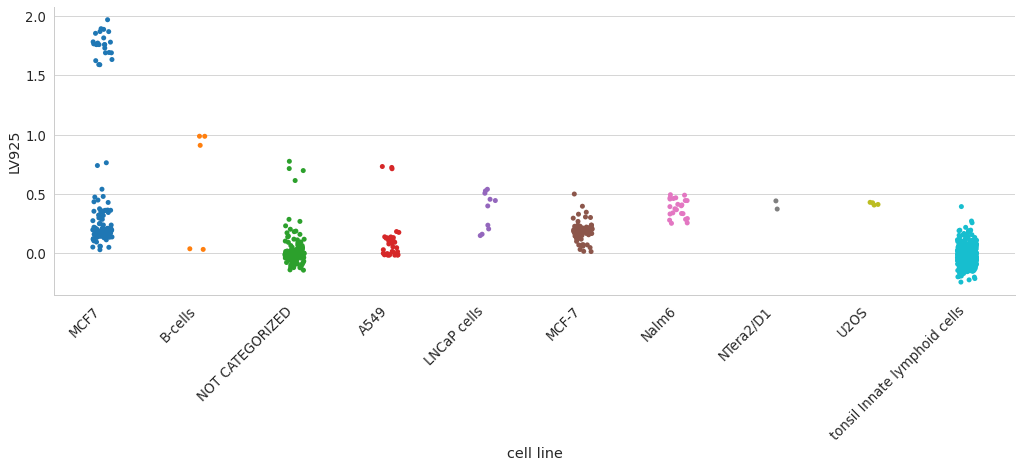

In [37]:
with sns.plotting_context("paper", font_scale=1.5), sns.axes_style("whitegrid"):
    sns.catplot(
        data=final_plot_data,
        y=LV_NAME,
        x=SELECTED_ATTRIBUTES[0],
        order=attr_order,
        kind="strip",
        height=5,
        aspect=3,
    )
    plt.xticks(rotation=45, horizontalalignment="right")

    # You can save the figure if you uncomment the code below
    # the figure will be created under ${DATA_FOLDER}/results/demo

    plt.savefig(
        OUTPUT_CELL_TYPE_FILEPATH,
        bbox_inches="tight",
        facecolor="white",
    )

# Debug

Now that you have the figure for your LV, you can debug some things.
For example, you'll see above that some samples are "NOT CATEGORIZED".
Let's see which are those:

In [38]:
with pd.option_context(
    "display.max_rows", None, "display.max_columns", None, "display.max_colwidth", None
):
    _tmp = final_plot_data[
        final_plot_data[SELECTED_ATTRIBUTES[0]].str.contains("MCF7")
    ]
    display(_tmp.head(20))

cell line     LV925
project   run                          
SRP018256 SRR653421      MCF7  1.967775
SRP013239 SRR497904      MCF7  1.892216
          SRR497906      MCF7  1.886486
SRP018256 SRR653425      MCF7  1.868339
SRP013239 SRR497905      MCF7  1.867609
SRP018256 SRR653422      MCF7  1.853175
SRP013239 SRR497920      MCF7  1.814641
          SRR497908      MCF7  1.781397
          SRR497917      MCF7  1.778907
          SRR497914      MCF7  1.771237
          SRR497907      MCF7  1.766542
          SRR497912      MCF7  1.764595
SRP018256 SRR653426      MCF7  1.760274
SRP013239 SRR497909      MCF7  1.758414
          SRR497913      MCF7  1.758160
          SRR497918      MCF7  1.758105
          SRR497916      MCF7  1.757674
          SRR497910      MCF7  1.729348
          SRR497923      MCF7  1.691748
          SRR497911      MCF7  1.689197

We don't have information about cell type/tissue for these.
But we can manually go to the URL showed before and check out.
For example, for `SRP015360` we can open our browser with this URL:
https://trace.ncbi.nlm.nih.gov/Traces/sra/?study=SRP018256, and see that the samples were taken from neutrophils.

If you need to see which information is provided by each SRP, you can again use the code below:

In [39]:
# what is there in these projects?
lv_data.loc[["SRP018256"]].dropna(how="all", axis=1).sort_values(
    LV_NAME, ascending=False
).head(60)

cell line treatement time                       treatment  \
project   run                                                                   
SRP018256 SRR653421      MCF7               0                       untreated   
          SRR653425      MCF7              40  treated for 40 minutes with E2   
          SRR653422      MCF7               0                       untreated   
          SRR653426      MCF7              40  treated for 40 minutes with E2   
          SRR653424      MCF7              10  treated for 10 minutes with E2   
          SRR653423      MCF7              10  treated for 10 minutes with E2   

                        LV925  
project   run                  
SRP018256 SRR653421  1.967775  
          SRR653425  1.868339  
          SRR653422  1.853175  
          SRR653426  1.760274  
          SRR653424  1.632622  
          SRR653423  1.588926

Now you can go back to section `Standardize cell type names` in this notebook and adjust according to this findings to improve the figure.
Once you are happy, you can remove the `NOT CATEGORIZED` items by uncommenting the code in `Delete samples with no tissue/cell type information`.